# Multi-Agent Debate Analysis

This notebook analyzes the results of 5 simulated debates between four AI characters — **Alice, Bob, Carol, and David** — on the topic of AI use in schools.

Each debate ran for 3 rounds. In each round, characters spoke, listened, updated their beliefs, and remembered what was said.

**What this notebook shows:**
1. 📈 **Stance Evolution** — Did each character get more or less supportive over time?
2. 📉 **Convergence Curve** — Did the group start agreeing more as the debate went on?
3. 🔗 **Influence Network** — Who was most convincing? Who changed whose mind?
4. 🎯 **Belief Drift** — How much did each character's opinion shift from their starting point?
5. 🔵 **Theme Overlap** — Which topics kept coming up across different debate sessions?

---

In [1]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from matplotlib_venn import venn2

%matplotlib inline

In [ ]:

# --- Agent identity ---
AGENT_NAMES  = ["Alice", "Bob", "Carol", "David"]
AGENT_COLORS = {"Alice": "#4C9BE8", "Bob": "#E85C5C", "Carol": "#6DBF6D", "David": "#F5A623"}
STANCE_TO_NUM = {
    "supportive": 1, "leaning_supportive": 1,
    "balanced": 0,
    "skeptical": -1, "leaning_skeptical": -1,
}

# --- Topics the simulation tracks ---
KEY_THEMES = [
    "critical thinking", "over-rely", "dependency", "misuse", "fairness",
    "creativity", "personalize", "personalized", "guidelines", "boundaries",
    "responsibility", "responsible", "access", "equity", "engagement",
    "brainstorm", "research", "feedback", "learning", "harm",
    "benefits", "risks", "moderation", "integrity", "shortcuts",
    "skills", "independent", "reliance", "support", "adoption"
]

# --- Helper functions ---
def load_trial(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def extract_themes(text):
    text = text.lower()
    return {t for t in KEY_THEMES if t in text}

def get_trial_themes(trial):
    themes = set()
    for agent in trial["agents"]:
        for trace in agent["traces"]:
            for field in ["observation_summary", "thought", "influence_analysis",
                          "updated_belief", "updated_goal", "message"]:
                themes |= extract_themes(trace.get(field, ""))
        themes |= extract_themes(agent.get("final_belief", ""))
        for mem in agent.get("memories", []):
            themes |= extract_themes(mem)
    return themes

def get_trial_stances(trial):
    return {agent["name"]: agent["stance_history"] for agent in trial["agents"]}

def parse_influencer(text):
    for name in AGENT_NAMES:
        if name.lower() in text.lower():
            return name
    return None


In [3]:
paths = sorted(glob.glob("trial_*.json"))
if not paths:
    print("No trial_*.json files found. Run main.py first.")
else:
    trials      = [load_trial(p) for p in paths]
    labels      = [f"Trial {t['trial_id']}" for t in trials]
    theme_sets  = [get_trial_themes(t) for t in trials]
    all_stances = [get_trial_stances(t) for t in trials]
    num_rounds  = max(len(v) for s in all_stances for v in s.values())
    print(f"Loaded {len(trials)} trial(s) — {num_rounds} rounds each: {labels}")

Loaded 5 trial(s) — 5 rounds each: ['Trial 1', 'Trial 2', 'Trial 3', 'Trial 4', 'Trial 5']


---
## 📈 Chart 1 — Stance Evolution

**What you're looking at:** Each panel is one character. The lines show whether they were *supportive*, *balanced*, or *skeptical* in each round of the debate — across all 5 trials (one colored line per trial).

**How to read it:**
- A line going **up** → the character became more in favor of AI in schools
- A line going **down** → they became more skeptical
- A **flat line** → they didn't change their stance that round
- When all 5 colored lines follow the same path → that character behaved consistently no matter the trial

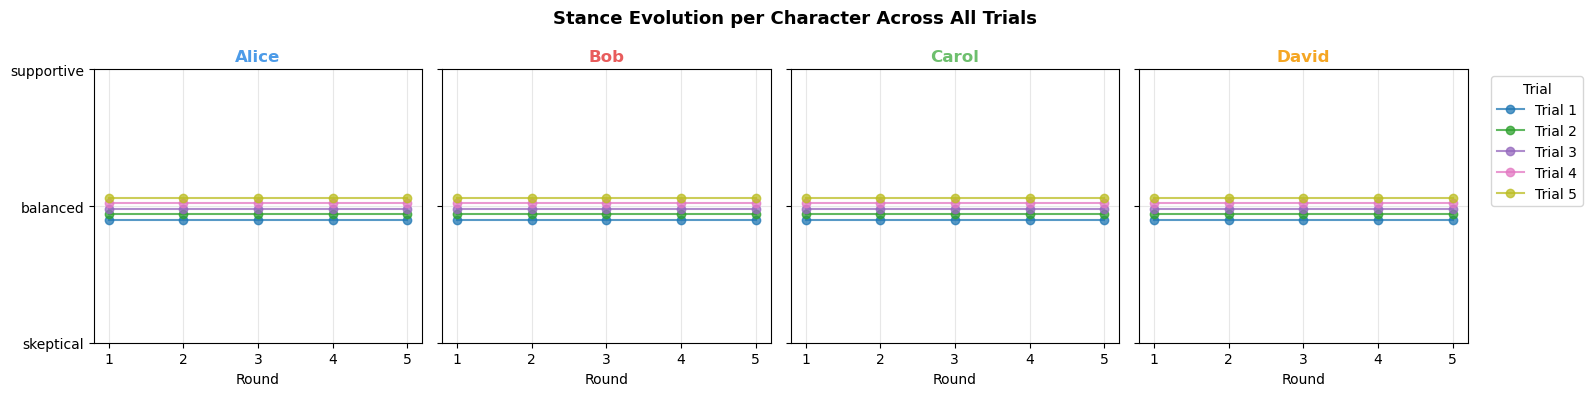

In [4]:
fig, axes = plt.subplots(1, len(AGENT_NAMES), figsize=(4 * len(AGENT_NAMES), 4), sharey=True)
fig.suptitle("Stance Evolution per Character Across All Trials", fontsize=13, fontweight="bold")

for ax, agent in zip(axes, AGENT_NAMES):
    for i, (stances, label) in enumerate(zip(all_stances, labels)):
        history = stances.get(agent, [])
        nums    = [STANCE_TO_NUM.get(s, 0) for s in history]
        rounds  = list(range(1, len(nums) + 1))
        jitter  = (i - len(labels) / 2) * 0.04
        ax.plot(rounds, [n + jitter for n in nums], marker="o", label=label,
                alpha=0.75, color=plt.cm.tab10(i / len(labels)))

    ax.set_title(agent, color=AGENT_COLORS[agent], fontweight="bold")
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["skeptical", "balanced", "supportive"])
    ax.set_xlabel("Round")
    ax.set_xticks(range(1, num_rounds + 1))
    ax.grid(True, alpha=0.3)

axes[-1].legend(title="Trial", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("stance_evolution.png", dpi=150)
plt.show()

---
## 📉 Chart 2 — Convergence Curve

**What you're looking at:** This chart tracks whether the 4 characters moved toward *agreement* as the debate progressed, for each of the 5 trials.

**How to read it:**
- The Y-axis measures how *spread out* the characters' opinions are — think of it as the gap between the most positive and most negative person
- **Going down** = the group is converging — everyone is landing on a similar view
- **Staying flat or going up** = they stayed divided even after debating
- A score near **0** means near-perfect agreement; a score near **1** means the group is still split

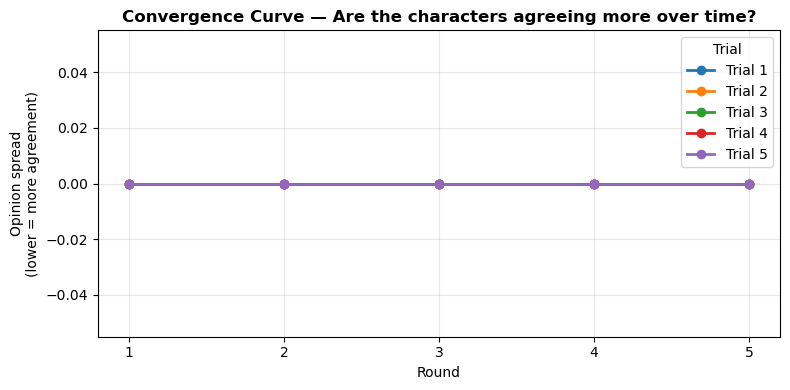

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

for stances, label in zip(all_stances, labels):
    agents_list    = list(stances.keys())
    std_per_round  = []
    for r in range(num_rounds):
        values = [STANCE_TO_NUM.get(stances[a][r], 0) for a in agents_list if r < len(stances[a])]
        if values:
            std_per_round.append(np.std(values))
    ax.plot(range(1, len(std_per_round) + 1), std_per_round, marker="o", label=label, linewidth=2)

ax.set_title("Convergence Curve — Are the characters agreeing more over time?", fontsize=12, fontweight="bold")
ax.set_xlabel("Round")
ax.set_ylabel("Opinion spread\n(lower = more agreement)")
ax.set_xticks(range(1, num_rounds + 1))
ax.legend(title="Trial")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("convergence_curve.png", dpi=150)
plt.show()

---
## 🔗 Chart 3 — Influence Network

**What you're looking at:** A map of who was convincing whom across all 5 trials. Each arrow points from the person who *influenced* someone to the person who *was influenced*.

**How to read it:**
- **Thicker arrows** = that influence happened more often across debates
- The number on each arrow is the raw count of times that influence was recorded
- A character with many arrows pointing *away* from them is a persuader
- A character with many arrows pointing *toward* them tends to shift their view based on others

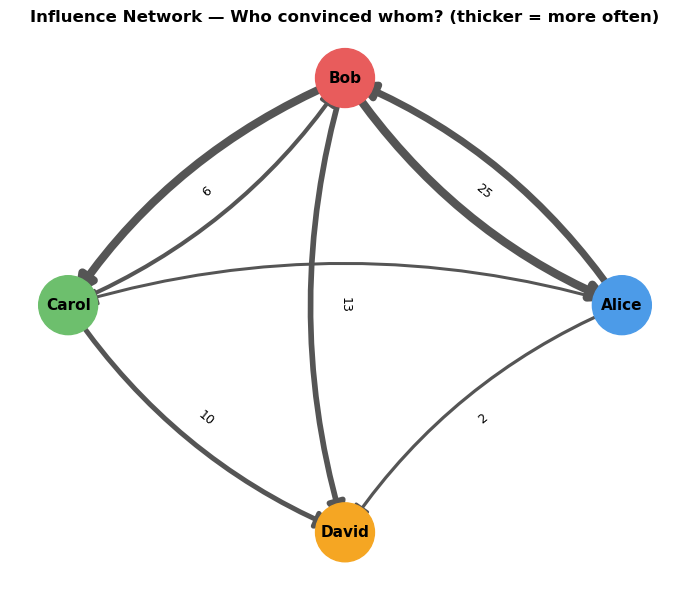

In [6]:
counts = {}
for trial in trials:
    for agent in trial["agents"]:
        influenced = agent["name"]
        for trace in agent["traces"]:
            influencer = parse_influencer(trace.get("influence_analysis", ""))
            if influencer and influencer != influenced:
                key = (influencer, influenced)
                counts[key] = counts.get(key, 0) + 1

G = nx.DiGraph()
G.add_nodes_from(AGENT_NAMES)
for (src, dst), weight in counts.items():
    G.add_edge(src, dst, weight=weight)

fig, ax = plt.subplots(figsize=(7, 6))
pos          = nx.circular_layout(G)
node_colors  = [AGENT_COLORS.get(n, "#aaaaaa") for n in G.nodes()]
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w        = max(edge_weights) if edge_weights else 1

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G, pos,
    width=[2 + 4 * (w / max_w) for w in edge_weights],
    edge_color="#555555", arrows=True, arrowsize=25,
    connectionstyle="arc3,rad=0.15", ax=ax,
)
nx.draw_networkx_edge_labels(
    G, pos, edge_labels={(u, v): G[u][v]["weight"] for u, v in G.edges()},
    font_size=9, ax=ax
)

ax.set_title("Influence Network — Who convinced whom? (thicker = more often)", fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("influence_network.png", dpi=150)
plt.show()

---
## 🎯 Chart 4 — Belief Drift

**What you're looking at:** How much each character's *belief* (their internal opinion, not just their stance label) shifted from where they started — round by round, averaged across all 5 trials.

**How to read it:**
- **0.0** = no change at all from their starting belief
- **1.0** = their belief completely transformed
- The **shaded band** shows how much variation there was across trials — a wide band means some trials moved them a lot and others barely at all
- A character that spikes in round 2 then flattens may have had one big realization and then held their ground

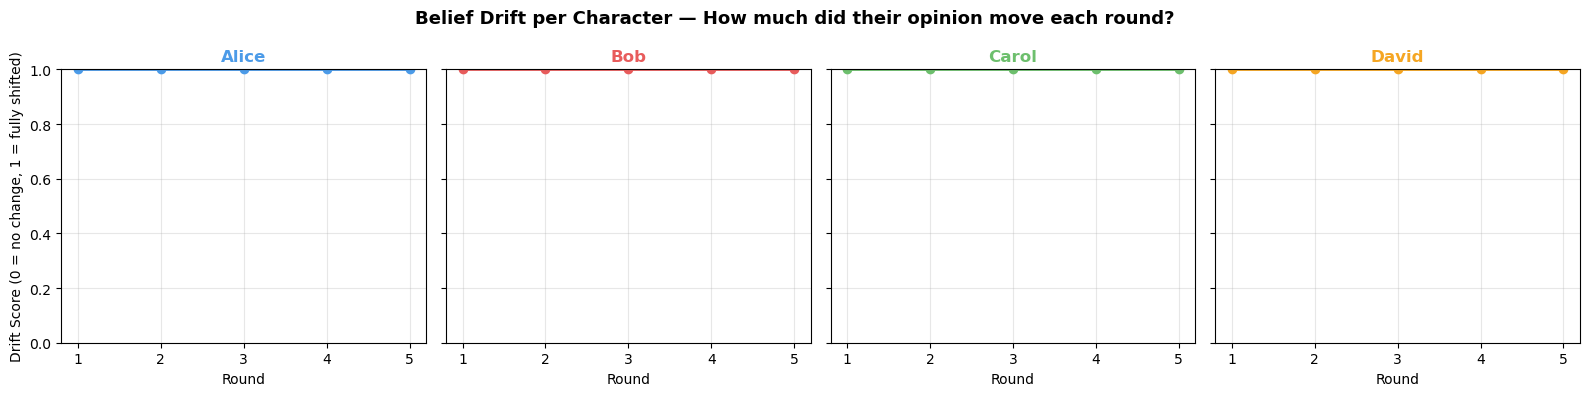

In [7]:
fig, axes = plt.subplots(1, len(AGENT_NAMES), figsize=(4 * len(AGENT_NAMES), 4), sharey=True)
fig.suptitle("Belief Drift per Character — How much did their opinion move each round?",
             fontsize=13, fontweight="bold")

for ax, agent_name in zip(axes, AGENT_NAMES):
    round_drifts = {}
    for trial in trials:
        for agent in trial["agents"]:
            if agent["name"] != agent_name:
                continue
            for trace in agent["traces"]:
                d = trace.get("belief_drift")
                if d is not None:
                    round_drifts.setdefault(trace["round"], []).append(d)

    color = AGENT_COLORS[agent_name]
    if not round_drifts:
        ax.text(0.5, 0.5, "no drift data\n(run new trials)",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
    else:
        rounds_sorted = sorted(round_drifts.keys())
        means = [np.mean(round_drifts[r]) for r in rounds_sorted]
        stds  = [np.std(round_drifts[r])  for r in rounds_sorted]
        ax.plot(rounds_sorted, means, marker="o", color=color, linewidth=2)
        ax.fill_between(rounds_sorted,
                        [m - s for m, s in zip(means, stds)],
                        [m + s for m, s in zip(means, stds)],
                        alpha=0.2, color=color)
        ax.set_xticks(rounds_sorted)

    ax.set_title(agent_name, color=color, fontweight="bold")
    ax.set_xlabel("Round")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Drift Score (0 = no change, 1 = fully shifted)")
plt.tight_layout()
plt.savefig("belief_drift.png", dpi=150)
plt.show()

---
## 🔵 Chart 5 — Theme Overlap (Venn Diagrams)

**What you're looking at:** Each Venn diagram compares two consecutive debate trials and shows which discussion topics they shared vs. which were unique to one session.

**How to read it:**
- The **overlapping center** = topics that came up in *both* of those trials
- The **left/right edges** = topics that only appeared in one of the two trials
- A large overlap means the debates consistently circled around the same core issues
- Topics that keep appearing in the center across all pairs are the ones the simulation gravitates toward most

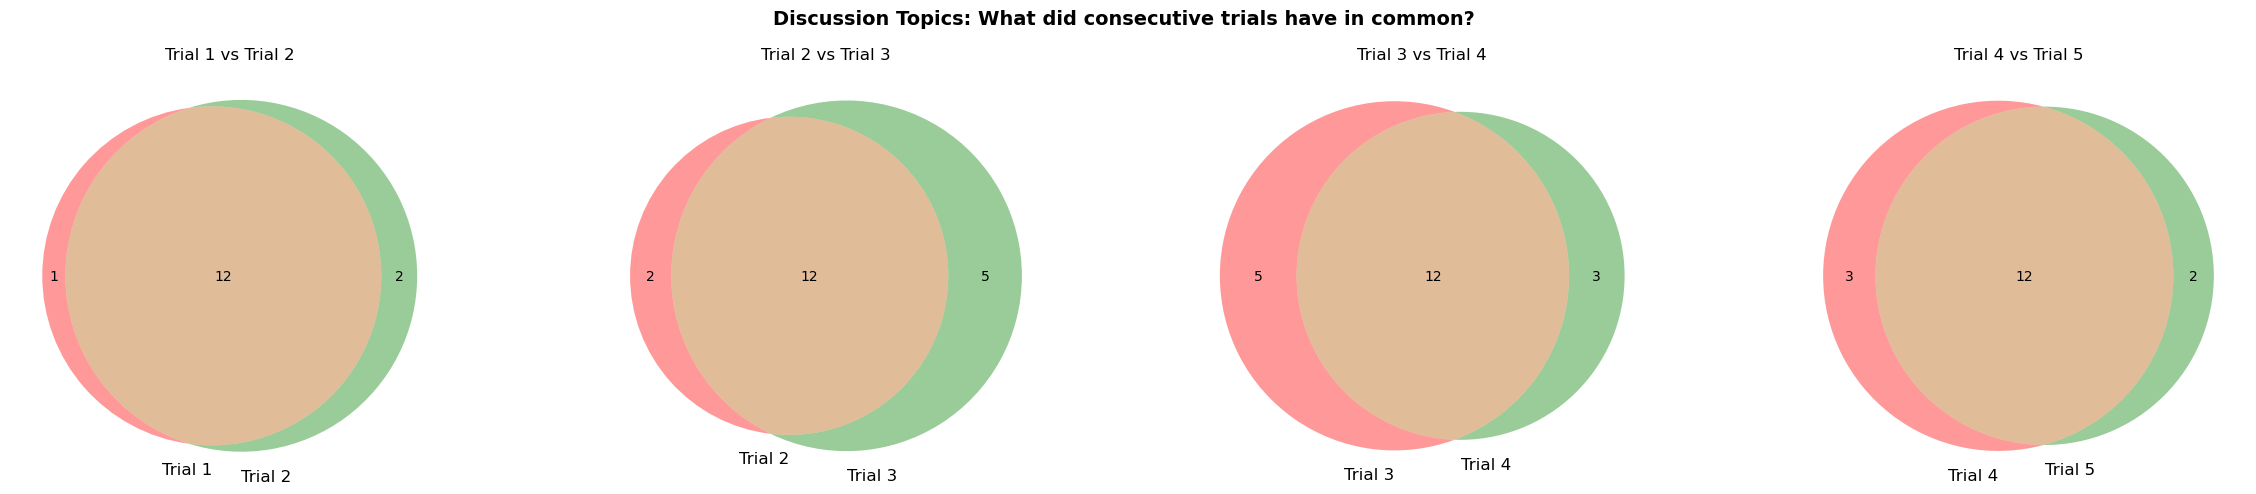

In [8]:
pairs = [(i, i + 1) for i in range(len(theme_sets) - 1)]
fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5))
if len(pairs) == 1:
    axes = [axes]

for ax, (i, j) in zip(axes, pairs):
    venn2([theme_sets[i], theme_sets[j]], set_labels=(labels[i], labels[j]), ax=ax)
    ax.set_title(f"{labels[i]} vs {labels[j]}")

fig.suptitle("Discussion Topics: What did consecutive trials have in common?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("venn_diagram.png", dpi=150)
plt.show()

---
## 📋 Theme Summary — What topics came up across all trials?

This section prints the themes that appeared in **every single trial** (the consistent core of the debate), and any topics that were **unique** to just one trial.

In [9]:
shared_all = theme_sets[0].copy()
for s in theme_sets[1:]:
    shared_all &= s

unique = [
    s - set().union(*[theme_sets[j] for j in range(len(theme_sets)) if j != i])
    for i, s in enumerate(theme_sets)
]

print(f"Topics that came up in ALL {len(trials)} trials:")
for t in sorted(shared_all):
    print(f"  • {t}")

print()
for i, label in enumerate(labels):
    if unique[i]:
        print(f"Only in {label}: {', '.join(sorted(unique[i]))}")

all_themes = set().union(*theme_sets)
print(f"\nAll topics observed across any trial ({len(all_themes)} total):")
print("  " + ", ".join(sorted(all_themes)))

Topics that came up in ALL 5 trials:
  • critical thinking
  • dependency
  • guidelines
  • independent
  • learning
  • reliance
  • responsible
  • skills
  • support

Only in Trial 3: misuse, over-rely, shortcuts
Only in Trial 4: research

All topics observed across any trial (21 total):
  adoption, benefits, boundaries, brainstorm, creativity, critical thinking, dependency, engagement, guidelines, independent, learning, misuse, moderation, over-rely, reliance, research, responsible, risks, shortcuts, skills, support
